# Train a Bayesian Layer Model for MNIST classification

In this notebook, we will train an MNIST convolutional classifier with a Bayesian last layer. First, we train a determinstic classifier to obtain a MAP estimate of the weights. Then, we replace the last layer of this model with a Bayesian last layer and train the layer using Variational Inference (we keep the backbone fixed).

We allow a choice between:
- Classifier dominated backbone
- Joint training backbone
- Autoencoder dominated backbone

## Setup


In [1]:
inDrive = True

In [2]:
import sys
import os

if inDrive:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Hybrid-CLUE/MyImplementation/testing_notebooks')

# Add the parent directory to the system path
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

Mounted at /content/drive


Import libraries

In [3]:
import importlib
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

import models.BLL
import models.mnist_classifier_BLL
import train
import sampler
import models.regene_models


Set the configuration

In [4]:
# 1. Configuration
class Config:
    # Data
    batch_size = 512

    # BLL training
    bll_epochs = 100
    bll_lr = 0.001
    patience = 10

    # Hardware
    device = 'cuda' if torch.cuda.is_available() \
    else 'mps' if torch.backends.mps.is_available() \
    else 'cpu'

cfg = Config()

Load the Datasets

In [5]:
# Load the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

# Split training set into train and validation
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = torch.utils.data.random_split(trainset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=cfg.batch_size, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)

Create a models and results directory if it doesn't exist

In [6]:
# Print the current working directory to help with file paths
import os
print(f"Current working directory: {os.getcwd()}")


models_dir = '../model_saves/big_test'
results_dir = '../results/big_test'
os.makedirs(models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

Current working directory: /content/drive/My Drive/Hybrid-CLUE/MyImplementation/testing_notebooks


In [7]:
dimensions = [16, 32, 64, 128, 256]

## Backbone
We'll start with the backbone loading. Options are either classifier_dominated, joint_training, or autoencoder_dominated.

### Load model

Load model

In [8]:
from models.regene_models import Decoder, Classifier
importlib.reload(models.regene_models)

models_list = []

for latent_dim in dimensions:
    decoder = models.regene_models.Decoder(latent_dim=latent_dim, device=cfg.device)
    backbone = models.regene_models.Classifier(latent_dim=latent_dim, num_classes=10, device=cfg.device)

    backbone.load(os.path.join(models_dir, f'joint_classifier_{latent_dim}.pth'))
    decoder.load(os.path.join(models_dir, f'joint_decoder_{latent_dim}.pth'))
    name = f'joint_training_BLL_{latent_dim}'
    models_list.append((backbone, decoder, name, latent_dim))

Loaded classifier model from: ../model_saves/big_test/joint_classifier_16.pth
Loaded decoder model from: ../model_saves/big_test/joint_decoder_16.pth
Loaded classifier model from: ../model_saves/big_test/joint_classifier_32.pth
Loaded decoder model from: ../model_saves/big_test/joint_decoder_32.pth
Loaded classifier model from: ../model_saves/big_test/joint_classifier_64.pth
Loaded decoder model from: ../model_saves/big_test/joint_decoder_64.pth
Loaded classifier model from: ../model_saves/big_test/joint_classifier_128.pth
Loaded decoder model from: ../model_saves/big_test/joint_decoder_128.pth
Loaded classifier model from: ../model_saves/big_test/joint_classifier_256.pth
Loaded decoder model from: ../model_saves/big_test/joint_decoder_256.pth


## Bayesian Last Layer - VI
Next we'll train a variational inference version of the Bayesian last layer for all backbones.


In [9]:
%pip install torchbnn

### Load the model

In [10]:
from models.BLL_VI import BayesianLastLayerVI
importlib.reload(models.BLL_VI)
from train import train_BLL_VI_classification
importlib.reload(train)


import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

save_dir = os.path.join(models_dir, 'BLL_VI')
os.makedirs(save_dir, exist_ok=True)

last_layer_models = []

for backbone, decoder, name, latent_dim in models_list:

    bll_vi = BayesianLastLayerVI(
        backbone=backbone,
        input_dim=latent_dim,  # Matches backbone's encoder output
        output_dim=10,  # MNIST classes
        device=cfg.device
    )

    # Verify all model components are on the correct device
    print(f"Backbone device: {next(bll_vi.backbone.parameters()).device}")
    print(f"Last layer device: {next(bll_vi.last_layer.parameters()).device}")

    vi_cost_tr, vi_cost_dev, vi_err_tr, vi_err_dev, vi_kl = train_BLL_VI_classification(
        net=bll_vi,
        batch_size=cfg.batch_size,
        nb_epochs=cfg.bll_epochs,
        trainset=trainset,
        valset=valset,
        device=cfg.device,
        lr=cfg.bll_lr,
        patience=cfg.patience,
        nb_its_dev=1,
        model_saves_dir=save_dir,
        model_name=name
    )
    last_layer_models.append(bll_vi)

Backbone device: cuda:0
Last layer device: cuda:0

Bayesian Last Layer (VI):
it 0/100, Jtr = 0.074, err = 0.921, KL = 0.747,    time: 4.341261 seconds

    Jdev = 16.787, err = 0.918

best validation error
it 1/100, Jtr = 0.047, err = 0.881, KL = 0.498,    time: 2.337366 seconds

    Jdev = 11.505, err = 0.824

best validation error
it 2/100, Jtr = 0.039, err = 0.839, KL = 0.415,    time: 2.496210 seconds

    Jdev = 8.092, err = 0.724

best validation error
it 3/100, Jtr = 0.033, err = 0.791, KL = 0.396,    time: 2.379597 seconds

    Jdev = 5.953, err = 0.607

best validation error
it 4/100, Jtr = 0.029, err = 0.749, KL = 0.403,    time: 2.677681 seconds

    Jdev = 4.322, err = 0.521

best validation error
it 5/100, Jtr = 0.024, err = 0.691, KL = 0.422,    time: 2.323582 seconds

    Jdev = 2.932, err = 0.447

best validation error
it 6/100, Jtr = 0.020, err = 0.655, KL = 0.451,    time: 2.347480 seconds

    Jdev = 1.846, err = 0.343

best validation error
it 7/100, Jtr = 0.019, er

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Test the models
To check for Bayesian behaviour, we find an uncertain prediction and visualize multiple samples from the posterior.


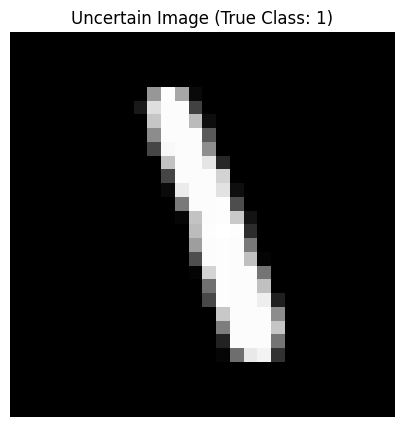

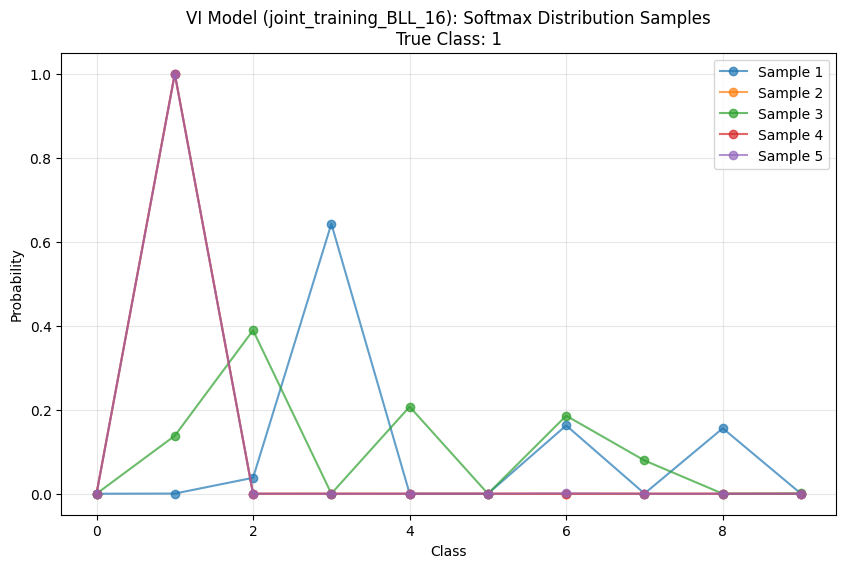

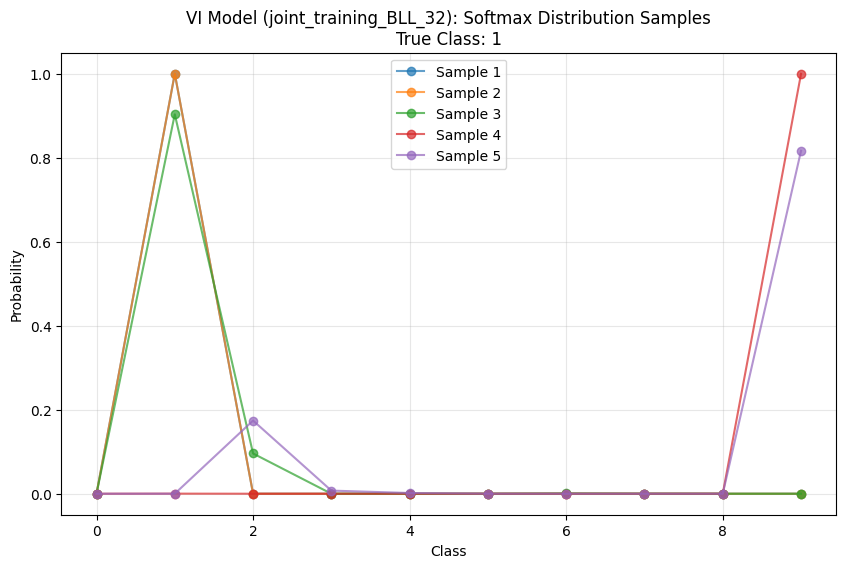

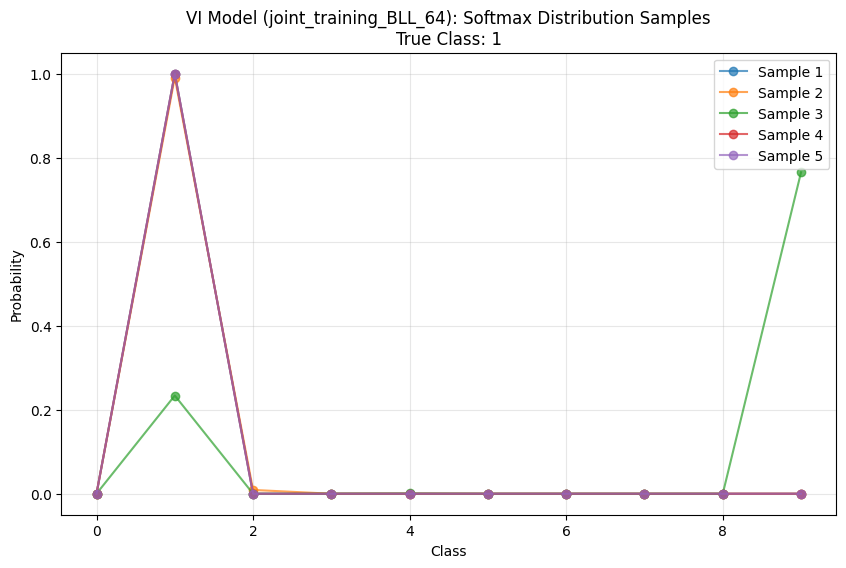

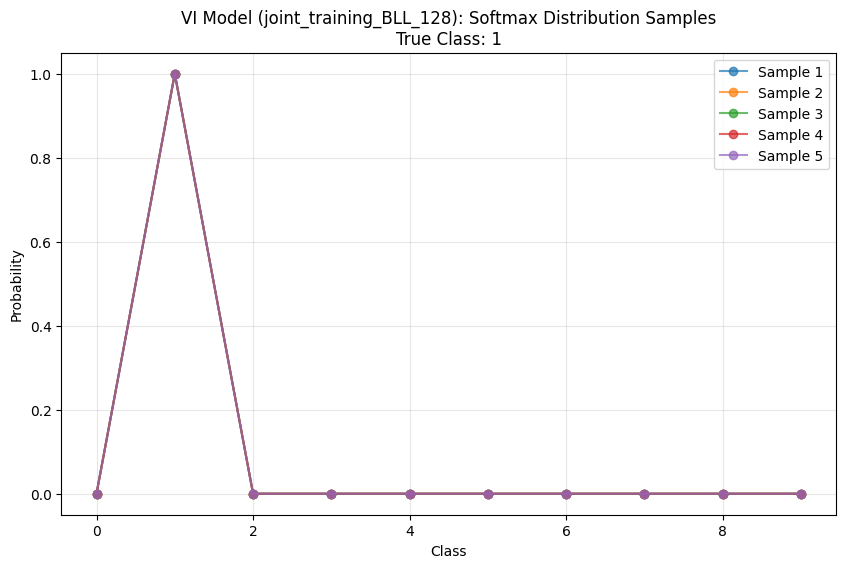

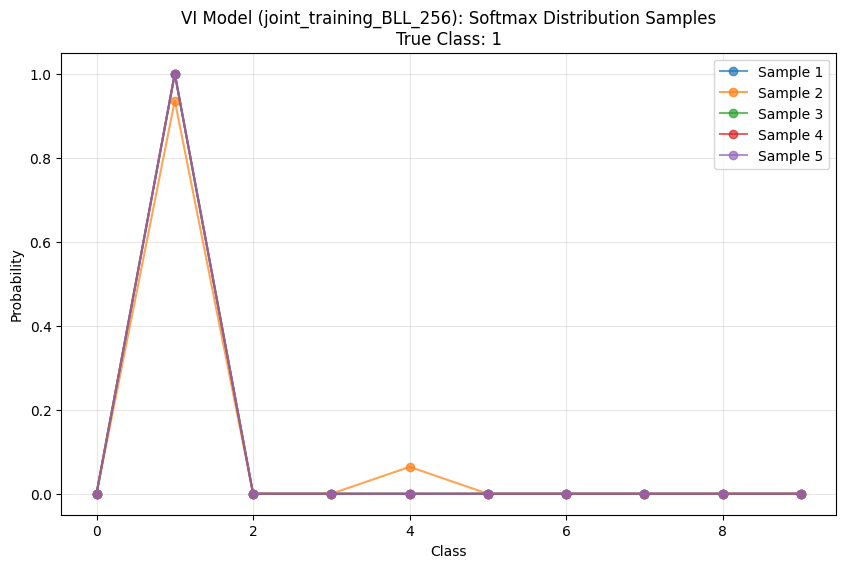

In [13]:
import torch.nn.functional as F

# Search for an uncertain prediction across all models
test_iter = iter(testloader)
found_uncertain = False
max_tries = 100
num_samples = 5

try:
    while not found_uncertain and max_tries > 0:
        x, y = next(test_iter)
        max_tries -= 1

        # Look at each example in the batch
        for i in range(len(x)):
            x_single = x[i:i+1].to(cfg.device)
            y_single = y[i:i+1]

            # Check if this example is uncertain across all models
            all_models_uncertain = True

            for model in last_layer_models:
                # Get multiple predictions for this single example
                outputs = []
                with torch.no_grad():
                    for _ in range(num_samples):
                        logits = model(x_single)
                        probs = F.softmax(logits, dim=1)
                        outputs.append(probs)

                # Stack predictions
                probs = torch.stack(outputs)  # Shape: [num_samples, 1, num_classes]
                probs = probs.squeeze(1)  # Remove batch dimension -> [num_samples, num_classes]

                # Check if predictions are not all highly confident
                max_probs = probs.max(dim=1)[0]
                if max_probs.mean() >= 0.99:  # If average confidence is high
                    all_models_uncertain = False
                    break

            if all_models_uncertain:
                found_uncertain = True
                uncertain_x = x_single
                uncertain_y = y_single
                break

except StopIteration:
    if not found_uncertain:
        print("Could not find uncertain prediction in entire test set")

# If we found an uncertain example, plot the softmax distributions for each model
if found_uncertain:
    # Display the uncertain image
    plt.figure(figsize=(5, 5))
    img = uncertain_x.squeeze().cpu()
    if img.shape[0] == 1:  # If grayscale, remove channel dimension
        img = img.squeeze(0)
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.axis('off')
    plt.title(f'Uncertain Image (True Class: {uncertain_y.item()})')
    plt.show()

    # Plot the softmax distributions for each model
    for idx, model in enumerate(last_layer_models):
        # Get multiple predictions for this single example
        outputs = []
        with torch.no_grad():
            for _ in range(num_samples):
                logits = model(uncertain_x)
                probs = F.softmax(logits, dim=1)
                outputs.append(probs)

        # Stack predictions
        probs = torch.stack(outputs)  # Shape: [num_samples, 1, num_classes]
        probs = probs.squeeze(1)  # Remove batch dimension -> [num_samples, num_classes]

        # Plot the softmax distributions
        plt.figure(figsize=(10, 6))
        x_axis = range(probs.shape[1])  # Range over number of classes

        for i in range(num_samples):
            plt.plot(x_axis, probs[i].detach().cpu().numpy(), 'o-', alpha=0.7, label=f'Sample {i+1}')

        model_name = f"Model {idx+1}" if idx < len(models_list) else f"Model {idx+1}"
        if idx < len(models_list):
            model_name = models_list[idx][2]  # Use the name from models_list

        plt.xlabel('Class')
        plt.ylabel('Probability')
        plt.title(f'VI Model ({model_name}): Softmax Distribution Samples\nTrue Class: {uncertain_y.item()}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("No uncertain examples found. Try increasing max_tries or adjusting the uncertainty threshold.")

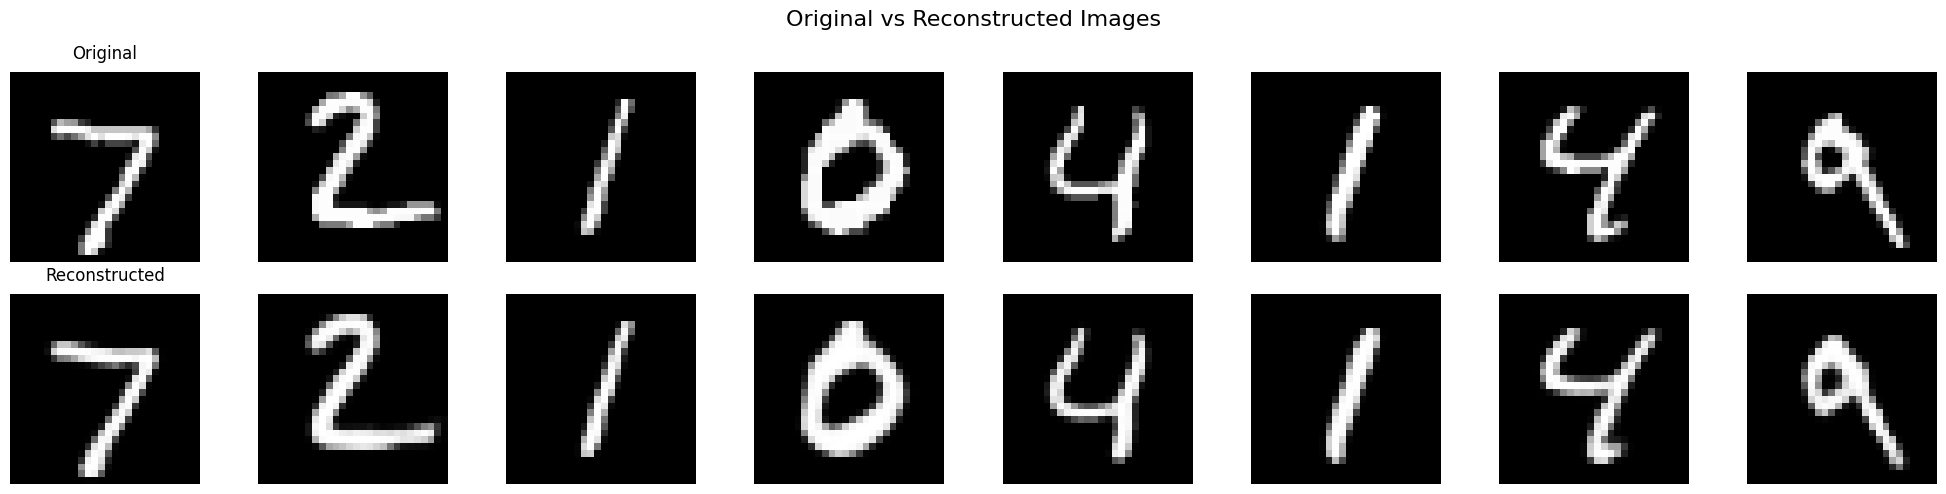

Reconstruction MSE: 0.0029


In [14]:
# Get test images
test_images, test_labels = next(iter(testloader))
test_images = test_images.to(cfg.device)

# Get reconstructions using the classifier and decoder
with torch.no_grad():
    # Get latent representations from classifier
    latent_reps, _ = backbone(test_images)  # Returns (latent_rep, logits)
    # Reconstruct using decoder
    reconstructions = decoder(latent_reps)

# Plot original and reconstructed images
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Original vs Reconstructed Images', fontsize=16)

# Plot original images
for i in range(8):
    axes[0,i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0,i].axis('off')
    if i == 0:
        axes[0,i].set_title('Original', pad=10)

# Plot reconstructions
for i in range(8):
    axes[1,i].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    axes[1,i].axis('off')
    if i == 0:
        axes[1,i].set_title('Reconstructed', pad=10)

plt.tight_layout()
plt.show()

# Optionally, calculate reconstruction error
mse = nn.MSELoss()
recon_error = mse(reconstructions, test_images)
print(f'Reconstruction MSE: {recon_error.item():.4f}')